In [2]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

In [3]:
START_YEAR = 1891
END_YEAR = 2025

OUTPUT_MONTHLY = "../data/processed/cyclone_monthly_1891_2025.csv"
OUTPUT_YEARLY = "../data/processed/cyclone_yearly_1891_2025.csv"

# Bay of Bengal bounding box
LAT_MIN = 5
LAT_MAX = 25
LON_MIN = 80
LON_MAX = 100

In [4]:
df = pd.read_csv("../data/raw/ibtracs.All.list.v04r00.csv")

print("Raw dataset shape:", df.shape)

C:\Users\dasgu\AppData\Local\Temp\ipykernel_13164\2184427719.py:1: DtypeWarning: Columns (1,2,8,9,14,19,20,161,162) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/ibtracs.All.list.v04r00.csv")


Raw dataset shape: (716166, 163)


In [6]:
columns = df.columns
print("Columns in the dataset:", columns)

Columns in the dataset: Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON',
       ...
       'BOM_GUST_PER', 'REUNION_GUST', 'REUNION_GUST_PER', 'USA_SEAHGT',
       'USA_SEARAD_NE', 'USA_SEARAD_SE', 'USA_SEARAD_SW', 'USA_SEARAD_NW',
       'STORM_SPEED', 'STORM_DIR'],
      dtype='object', length=163)


In [36]:
df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")

df["YEAR"] = df["ISO_TIME"].dt.year
df["MONTH"] = df["ISO_TIME"].dt.month


C:\Users\dasgu\AppData\Local\Temp\ipykernel_23160\2607554070.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ISO_TIME"] = pd.to_datetime(df["ISO_TIME"], errors="coerce")


In [37]:
df.head

<bound method NDFrame.head of                   SID SEASON NUMBER BASIN SUBBASIN       NAME  \
0                       Year                                    
1       1842298N11080   1842      1    NI       BB  NOT_NAMED   
2       1842298N11080   1842      1    NI       BB  NOT_NAMED   
3       1842298N11080   1842      1    NI       BB  NOT_NAMED   
4       1842298N11080   1842      1    NI       BB  NOT_NAMED   
...               ...    ...    ...   ...      ...        ...   
716161  2024147N19089   2024     27    NI       BB      REMAL   
716162  2024147N19089   2024     27    NI       BB      REMAL   
716163  2024147N19089   2024     27    NI       BB      REMAL   
716164  2024147N19089   2024     27    NI       BB      REMAL   
716165  2024147N19089   2024     27    NI       BB      REMAL   

                  ISO_TIME NATURE            LAT           LON  ...  \
0                      NaT         degrees_north  degrees_east  ...   
1      1842-10-25 03:00:00     NR        10.900

In [38]:
df = df[(df["YEAR"] >= START_YEAR) & (df["YEAR"] <= END_YEAR)]

In [39]:

df = df[df["BASIN"] == "NI"]  # North Indian Ocean

In [40]:
df.shape

(50497, 165)

In [41]:
df["WIND"] = pd.to_numeric(df["USA_WIND"], errors="coerce")

# Severe cyclone threshold
df["SEVERE"] = df["WIND"] >= 64  # knots

df["sea_region"] = np.where(df["LON"] > 80, "bob", "arabian")

In [42]:
monthly = df.groupby(["YEAR", "MONTH"]).agg(
    cyclones_total=("SID", "nunique"),
    max_wind=("WIND", "max"),
    severe_total=("SEVERE", "sum")
)

monthly = monthly.reset_index()

# approximate disturbances
monthly["disturbances_total"] = monthly["cyclones_total"] * 2

# engineered features
monthly["severity_ratio"] = (
    monthly["severe_total"] / (monthly["cyclones_total"] + 1)
)

monthly["disturbance_ratio"] = (
    monthly["disturbances_total"] / (monthly["cyclones_total"] + 1)
)

monthly["target"] = (monthly["severe_total"] > 0).astype(int)

# rolling climate trend (5 year = 60 months)
monthly["cyclone_5yr_avg"] = (
    monthly["cyclones_total"]
    .rolling(window=60, min_periods=1)
    .mean()
)


In [43]:
yearly = monthly.groupby("YEAR").agg(
    cyclones_total=("cyclones_total", "sum"),
    disturbances_total=("disturbances_total", "sum"),
    severe_total=("severe_total", "sum")
)

yearly = yearly.reset_index()

yearly["severity_ratio"] = (
    yearly["severe_total"] / (yearly["cyclones_total"] + 1)
)

yearly["disturbance_ratio"] = (
    yearly["disturbances_total"] / (yearly["cyclones_total"] + 1)
)

yearly["target"] = (yearly["severe_total"] > 0).astype(int)

yearly["cyclone_5yr_avg"] = (
    yearly["cyclones_total"]
    .rolling(window=5, min_periods=1)
    .mean()
)

In [44]:
full_months = pd.DataFrame(
    {
        "YEAR": np.repeat(range(START_YEAR, END_YEAR + 1), 12),
        "MONTH": list(range(1, 13)) * (END_YEAR - START_YEAR + 1)
    }
)

In [45]:
monthly = full_months.merge(
    monthly,
    on=["YEAR", "MONTH"],
    how="left"
)

In [46]:
monthly["cyclones_total"] = monthly["cyclones_total"].fillna(0)
monthly["severe_total"] = monthly["severe_total"].fillna(0)
monthly["max_wind"] = monthly["max_wind"].fillna(0)
monthly["disturbances_total"] = monthly["disturbances_total"].fillna(0)

In [47]:
monthly["severity_ratio"] = (
    monthly["severe_total"] / (monthly["cyclones_total"] + 1)
)

monthly["disturbance_ratio"] = (
    monthly["disturbances_total"] / (monthly["cyclones_total"] + 1)
)

monthly["target"] = (monthly["severe_total"] > 0).astype(int)

In [48]:
monthly["target"].value_counts()

target
0    1537
1      83
Name: count, dtype: int64

In [49]:
monthly["season"] = monthly["MONTH"].map({
    1:"winter",
    2:"winter",
    3:"pre_monsoon",
    4:"pre_monsoon",
    5:"pre_monsoon",
    6:"monsoon",
    7:"monsoon",
    8:"monsoon",
    9:"post_monsoon",
    10:"post_monsoon",
    11:"post_monsoon",
    12:"winter"
})

In [50]:
monthly[monthly["target"] == 1].head()

,YEAR,MONTH,cyclones_total,max_wind,severe_total,disturbances_total,severity_ratio,disturbance_ratio,target,cyclone_5yr_avg,season
975,1972,4,1.0,85.0,6.0,2.0,3.00,1.0,1,2.366667,pre_monsoon
980,1972,9,3.0,80.0,15.0,6.0,3.75,1.5,1,2.400000,post_monsoon
982,1972,11,3.0,90.0,35.0,6.0,8.75,1.5,1,2.333333,post_monsoon
1006,1974,11,1.0,75.0,11.0,2.0,5.50,1.0,1,2.216667,post_monsoon
1012,1975,5,3.0,95.0,56.0,6.0,14.00,1.5,1,2.216667,pre_monsoon


In [51]:
monthly.groupby("MONTH")["target"].sum()

MONTH
1      0
2      0
3      0
4      6
5     22
6      7
7      0
8      0
9      3
10    11
11    24
12    10
Name: target, dtype: int64

In [52]:
monthly = pd.get_dummies(monthly, columns=["season"])

In [53]:
monthly["cyclones_prev_month"] = monthly["cyclones_total"].shift(1)

monthly["cyclones_prev_3mo"] = monthly["cyclones_total"].rolling(3).mean()

monthly["cyclones_prev_6mo"] = monthly["cyclones_total"].rolling(6).mean()

<Axes: xlabel='MONTH', ylabel='count'>

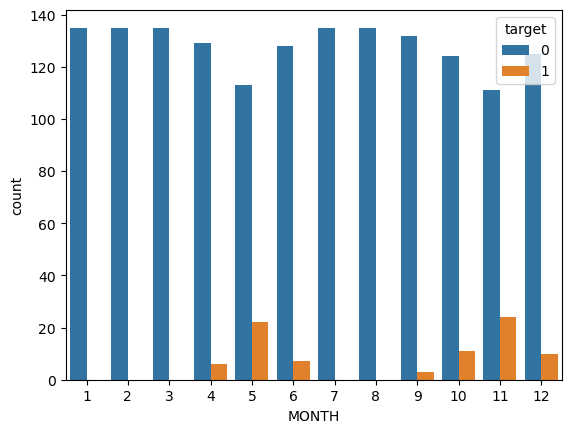

In [54]:
import seaborn as sns

sns.countplot(x="MONTH", hue="target", data=monthly)

In [55]:
monthly.to_csv(OUTPUT_MONTHLY, index=False)
yearly.to_csv(OUTPUT_YEARLY, index=False)

print("Saved monthly dataset:", OUTPUT_MONTHLY)
print("Saved yearly dataset:", OUTPUT_YEARLY)

print("Monthly rows:", len(monthly))
print("Yearly rows:", len(yearly))

Saved monthly dataset: ../data/processed/cyclone_monthly_1891_2025.csv
Saved yearly dataset: ../data/processed/cyclone_yearly_1891_2025.csv
Monthly rows: 1620
Yearly rows: 134
